# Assignment 03

The following assignment is divided in two parts:
- Part A: Run the cells that have already been coded for you to see and understand how Convolution 2D kernel works and, at the end, respond to the questions 1a, 1b, 2a, 2b
- Part B:  Run the cells that have already been coded for you to train the given Neural Network and then respond to the questions 03 to 10 in your video

**Note:**

Coding: 5%
video presentation: 5%
Total: 10%
But without YouTube presentation you receive no mark for the submission. In short, only submissions with YouTube link will be marked.

# PART A

## Image Convolution

In [1]:
# Import the necessary packages and libraries
import numpy as np
from PIL import Image
from scipy import misc
from skimage import data
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
%matplotlib inline
import requests
from io import BytesIO

/tmp/ipykernel_2441/2672511126.py:4: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


## Import the image

In [2]:
# Get the image from the URL
response = requests.get('https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTAHCp2ppBbfcPk9S5nE8gFFsZpDh0Exv9qUKXjehk_QszZHsV_pw&s')

In [3]:
# Visualize the content of the response
print(response.content)

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00\x84\x00\t\x06\x07\x12\x13\x12\x15\x13\x13\x12\x16\x16\x15\x15\x17\x17\x16\x15\x17\x18\x17\x17\x17\x17\x17\x17\x15\x15\x16\x17\x15\x17\x15\x19\x19\x1d( \x18\x1b&\x1b\x15\x15!1!%)+...\x17\x1f383-7(-.+\x01\n\n\n\x0e\r\x0e\x1a\x10\x10\x1b-&\x1e%--------------------+--//--------/----------------\xff\xc0\x00\x11\x08\x00\x8c\x01g\x03\x01\x11\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1c\x00\x00\x01\x05\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x02\x03\x04\x05\x06\x01\x07\x08\xff\xc4\x00L\x10\x00\x02\x00\x03\x05\x04\x06\x06\x05\t\x06\x05\x05\x01\x00\x00\x01\x02\x00\x03\x11\x04\x05\x12!1\x06AQq\x07\x13a\x81\x91\xa1"2Br\xb1\xc1#R\xd1\xe1\xf03Cb\x82\x92\xa2\xb2\xc2\xd2\x08\x14DSs\x93\x16\x17ET\xf14c\xa3\xb3\xe2\x15\xff\xc4\x00\x1b\x01\x01\x00\x03\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\xff\xc4\x00<\x11\x00\x02\x01\x02\x02\x06\x06\n\x00\x04\x07\x01\x00\x00\x00\

In [4]:
# BytesIO() buffers the image into the RAM
# Image.open() opens the buffered image
# np.array() transforms the image into a 3D array containing values from 0-255 corresponding to the RGB colour channels
input_img_arr = np.array(Image.open(BytesIO(response.content)))

## First let’s see the Image.




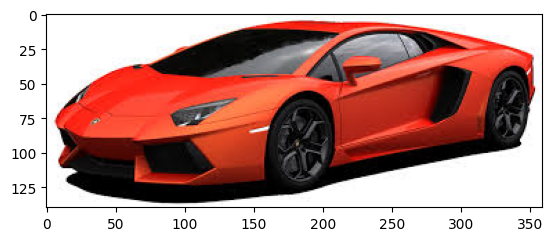

In [5]:


# Plot the resulting image from the array
plt.imshow(input_img_arr)

In [6]:
# Print the array shape
print(input_img_arr.shape)

# Compare the values of colour channels 0 and 1
print(np.array_equal(
        input_img_arr[:, :, 0],
        input_img_arr[:, :, 1]))

# Compare the values of colour channels 1 and 2
print(np.array_equal(
        input_img_arr[:, :, 1],
        input_img_arr[:, :, 2]))

(140, 359, 3)
False
False


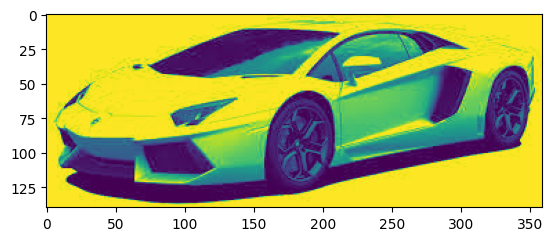

In [7]:
# Save the colour channel 0 in to the input_img_arr array variable and print it
input_img_arr = input_img_arr[:, :, 0]
plt.imshow(input_img_arr)

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
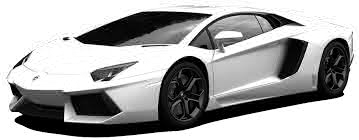

In [8]:
# Visualize the values inside of the resulting array
input_img_arr[:, :]

## Convolution with 2-D Kernels

How Convolution works?
https://miro.medium.com/max/790/1*1okwhewf5KCtIPaFib4XaA.gif

In [9]:
# Create a padded array by adding 2 rows and 2 columns (one of each at the beginning and another of each at the end)
padded_array = np.pad(input_img_arr, (1, 1), 'constant')

# Create the kernel
kernel = np.array([[0, 0, 0],
                   [0, 1, 0],
                   [0, 0, 0]])

#Create an output array filled with zeros with the same shape of input_img_arr
output_array = np.zeros(input_img_arr.shape)

In [10]:
#Compare both arrays
print("Original array shape:",input_img_arr.shape)
print("Padded array shape:",padded_array.shape)

Original array shape: (140, 359)
Padded array shape: (142, 361)


In [11]:
#Apply the kernel to the array values
for i in range(padded_array.shape[0]-2):
    for j in range(padded_array.shape[1]-2):
        temp_array = padded_array[i:i+3, j:j+3]
        output_array[i, j] = np.sum(temp_array*kernel)

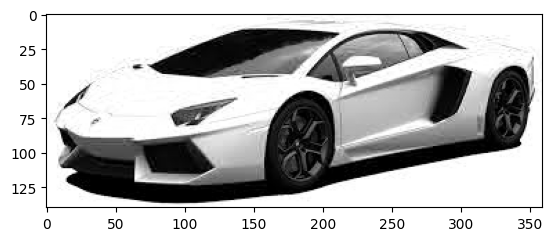

In [12]:
#Plot the resulting array
plt.imshow(output_array, cmap = plt.get_cmap('gray'))

## Standard Convolution

In [13]:
# Define a function to trim out the values between 0-255 range.
# This function will be called in the following function since the resulting array values can be negative or greater than 255
def squash_pixel_value(value):
    if value < 0:
        return 0
    elif value < 255:
        return value
    else:
        return 255

In [14]:
#Define a function to apply a Conv 2D Kernel to an image
def conv_2d_kernel(image_array_2d, kernel, squash_pixels = True):
    padded_array = np.pad(image_array_2d, (1, 1), 'constant')

    kernel_width = kernel.shape[0]
    kernel_height = kernel.shape[1]

    transformed_array = np.zeros(image_array_2d.shape)

    for i in range(padded_array.shape[0] - kernel_width + 1):
        for j in range(padded_array.shape[1] - kernel_height + 1):
            temp_array = padded_array[i:i+kernel_width, j:j+kernel_height]
            if squash_pixels:
                transformed_array[i, j] = squash_pixel_value(np.sum(temp_array*kernel))
            else:
                transformed_array[i, j] = np.sum(temp_array*kernel)
    return transformed_array

## Line detection
With image convolutions, you can easily detect lines. Here are four convolutions to detect horizontal, vertical and lines at 45 degrees:

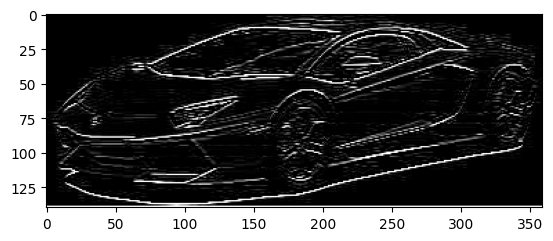

In [15]:
#Create a kernel to detect horizontal lines
horizontal_kernel = np.array([[-1, -1, -1],
                              [2, 2, 2],
                              [-1, -1, -1]])

#Apply the kernel to the image
transf_horizontal = conv_2d_kernel(input_img_arr, kernel = horizontal_kernel)

#Plot the resulting image
plt.imshow(transf_horizontal, cmap = plt.get_cmap('gray'))

### Questions 01-a and 01-b

#### 01-a: Based on the kernels represented on the above image, create a kernel to detect 45 degree lines using convolution, apply to the car's image and plot the result

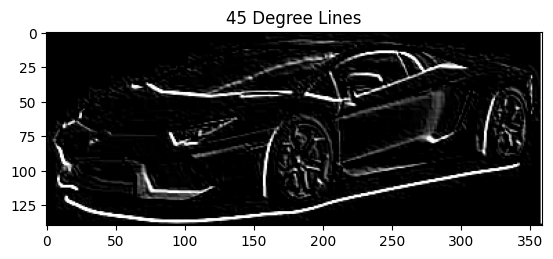

In [16]:
# Type your code here


kernel_45 = np.array([
    [0, -1, -1],
    [1, 0, -1],
    [1, 1, 0]
])

output_45 = conv_2d_kernel(input_img_arr, kernel_45)

plt.imshow(output_45, cmap='gray')
plt.title("45 Degree Lines")
plt.show()

#### 01-b: Based on the kernels represented on the above image, create a kernel to detect 135 degree lines using convolution, apply to the car's image and plot the result

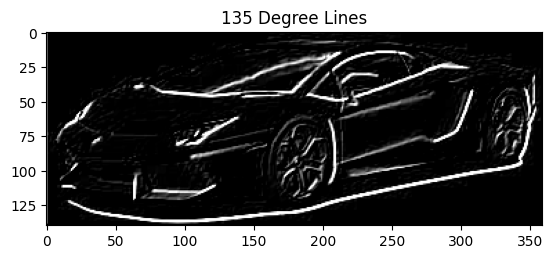

In [17]:
# Type your code here

kernel_135 = np.array([
    [-1, -1, 0],
    [-1, 0, 1],
    [0, 1, 1]
])

output_135 = conv_2d_kernel(input_img_arr, kernel_135)

plt.imshow(output_135, cmap='gray')
plt.title("135 Degree Lines")
plt.show()


## Edge Detection

### Question 02: Apply the following kernels to your image and plot the output

#### 02-a:

In [18]:
edge_kernel_1 = np.array([[1, 0, -1],
                          [0, 0, 0],
                          [-1, 0, 1]])

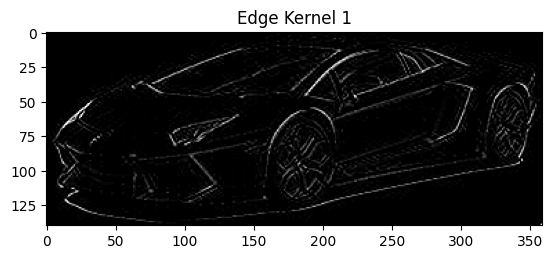

In [19]:
# Type your code here

output_edge1 = conv_2d_kernel(input_img_arr, edge_kernel_1)

plt.imshow(output_edge1, cmap='gray')
plt.title("Edge Kernel 1")
plt.show()


#### 02-b:

In [20]:
edge_kernel_2 = np.array([[0, 1, 0],
                          [1, -4, 1],
                          [0, 1, 0]])

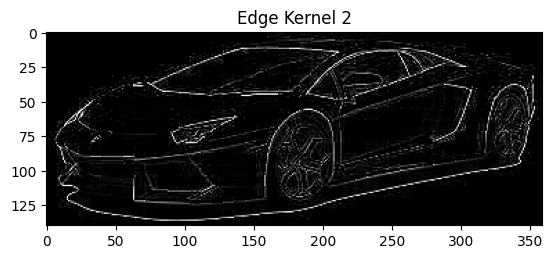

In [21]:
# Type your code here


output_edge2 = conv_2d_kernel(input_img_arr, edge_kernel_2)

plt.imshow(output_edge2, cmap='gray')
plt.title("Edge Kernel 2")
plt.show()


#### 02-c:

In [22]:
edge_kernel_3 = np.array([[-1, -1, -1],
                          [-1, 8, -1],
                          [-1, -1, -1]])

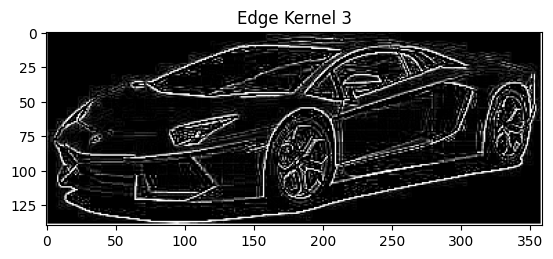

In [23]:
# Type your code here


output_edge3 = conv_2d_kernel(input_img_arr, edge_kernel_3)

plt.imshow(output_edge3, cmap='gray')
plt.title("Edge Kernel 3")
plt.show()


# PART B

## Importing Libraries

In [24]:
# Import the necessary packages and libraries
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from keras.constraints import max_norm
from keras.datasets import cifar10

## Preparing the dataset

Read more about cifar10 dataset here
https://www.cs.toronto.edu/~kriz/cifar.html

In [25]:
#load the dataset
(train_images, train_labels),(test_images, test_labels) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [26]:
# one hot encode target values
train_labels = to_categorical(train_labels,10)
test_labels = to_categorical(test_labels,10)

# convert from integers to floats
train_images = train_images.astype('float32')
test_images = test_images.astype('float32')

# normalize to range 0-1
train_images = train_images / 255.0
test_images = test_images / 255.0

## Building the neural network model

In [27]:
# Create the model
model = keras.Sequential([
          keras.layers.Conv2D(32, (3,3), padding='same',
                              activation='relu',
                              kernel_constraint=max_norm(3),
                              input_shape=(32, 32, 3)),
          keras.layers.MaxPooling2D((2, 2)),
          keras.layers.Flatten(),
          keras.layers.Dense(128, activation='relu'),
          keras.layers.Dense(10, activation='softmax'),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
# Model compilation
model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])

In [29]:
# Display a summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,050,890 (4.01 MB)

 Trainable params: 1,050,890 (4.01 MB)

 Non-trainable params: 0 (0.00 B)

## CustomCallback class for logging

In [30]:
# Create a Custom Callback class to be called during the training
class CustomCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(epoch % 5 ==0):
      print(" Finished epoch #",epoch)
      print('Accuracy resched train is',logs.get('accuracy'))
      print('Accuracy reached val is',logs.get('val_accuracy'))
      print()
      return

In [31]:
# Instantiate the Custom Callback
cc=CustomCallback()

## Training the Nework

In [32]:
# Train the Network with train_images and train_labels
history = model.fit(train_images,
                    train_labels,
                    epochs=50,
                    batch_size=256,
                    verbose=0,
                    validation_data=(test_images,test_labels),
                    callbacks=[cc])

 Finished epoch # 0
Accuracy resched train is 0.38989999890327454
Accuracy reached val is 0.48660001158714294

 Finished epoch # 5
Accuracy resched train is 0.6294999718666077
Accuracy reached val is 0.6021000146865845

 Finished epoch # 10
Accuracy resched train is 0.6897000074386597
Accuracy reached val is 0.6320000290870667

 Finished epoch # 15
Accuracy resched train is 0.7308599948883057
Accuracy reached val is 0.6517000198364258

 Finished epoch # 20
Accuracy resched train is 0.7610999941825867
Accuracy reached val is 0.6636999845504761

 Finished epoch # 25
Accuracy resched train is 0.7921199798583984
Accuracy reached val is 0.6491000056266785

 Finished epoch # 30
Accuracy resched train is 0.8176800012588501
Accuracy reached val is 0.6586999893188477

 Finished epoch # 35
Accuracy resched train is 0.8389800190925598
Accuracy reached val is 0.642300009727478

 Finished epoch # 40
Accuracy resched train is 0.8629199862480164
Accuracy reached val is 0.6452000141143799

 Finished e

## Plotting the Results

In [33]:
# Define a function to plot the results
def result_plotting():
  plt.figure(figsize=[8,6])
  plt.plot(history.history['accuracy'],'blue',linewidth=3.0)
  plt.plot(history.history['val_accuracy'],'red',ls='--',linewidth=3.0)
  plt.legend(['Training Accuracy','Validaion Accuracy'],fontsize=18,loc='lower right')
  plt.xlabel('Epochs',fontsize=16)
  plt.ylabel('Accuracy',fontsize=16)
  plt.title('Accuracy Curves',fontsize=16)

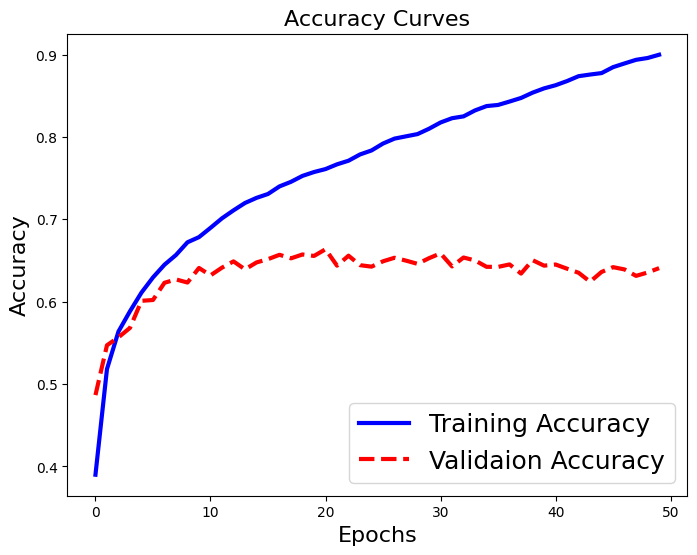

In [34]:
# Call the result_plotting() function
result_plotting()

### Questions 03 to 10

# 03: Did the network present signs of overfitting? If so, in which epoch?

**Answer:**

Yes, the network presented clear signs of overfitting.

This was most evident in the larger model, where the training accuracy continued to increase significantly, while the validation accuracy stopped improving and slightly decreased.

Based on the observed results, overfitting started approximately around epoch 10 to 15.

# 04: Write down how many layers this model has and identify their types

**Answer:**

The original model consists of 5 layers:

1. Conv2D  
2. MaxPooling2D  
3. Flatten  
4. Dense  
5. Dense  

So, the model includes one convolutional layer, one pooling layer, one flatten layer, and two fully connected dense layers.

# 05: Briefly explain what is the purpose of each of those layers

**Answer:**

The Conv2D layer is responsible for extracting important features from the input images, such as edges, shapes, and textures.

The MaxPooling2D layer reduces the spatial size of the feature maps while preserving the most important information, which helps improve efficiency and reduce overfitting.

The Flatten layer converts the 2D feature maps into a 1D vector so that the data can be passed into fully connected layers.

The first Dense layer learns higher-level patterns based on the extracted features.

The final Dense layer produces the output probabilities for each class using the softmax activation function.

# 06: Add one or more Convolution layers to your model and run it again.

> Hint: Don't modify the given code. Instead, copy and paste the given code below, then:
1. modify it to answer the current question
2.  run the cell below containing the fucntions ```model.compile()``` and ```model.fit()```.
3. once the training is complete, run the following cell containing the ```result_plotting()``` function

In [35]:
# Type your code here

model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),  # NEW
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])


In [36]:
# Compile your new model
model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])

# Train the Neural Network with your new model
history = model.fit(train_images,
                    train_labels,
                    epochs=50,
                    batch_size=256,
                    verbose=0,
                    validation_data=(test_images,test_labels),
                    callbacks=[cc])

 Finished epoch # 0
Accuracy resched train is 0.4520399868488312
Accuracy reached val is 0.5716000199317932

 Finished epoch # 5
Accuracy resched train is 0.7587000131607056
Accuracy reached val is 0.6797999739646912

 Finished epoch # 10
Accuracy resched train is 0.8766999840736389
Accuracy reached val is 0.6898999810218811

 Finished epoch # 15
Accuracy resched train is 0.9662200212478638
Accuracy reached val is 0.6812000274658203

 Finished epoch # 20
Accuracy resched train is 0.9882400035858154
Accuracy reached val is 0.6668999791145325

 Finished epoch # 25
Accuracy resched train is 0.9923800230026245
Accuracy reached val is 0.6704000234603882

 Finished epoch # 30
Accuracy resched train is 0.9999799728393555
Accuracy reached val is 0.6827999949455261

 Finished epoch # 35
Accuracy resched train is 1.0
Accuracy reached val is 0.6827999949455261

 Finished epoch # 40
Accuracy resched train is 1.0
Accuracy reached val is 0.6819000244140625

 Finished epoch # 45
Accuracy resched trai

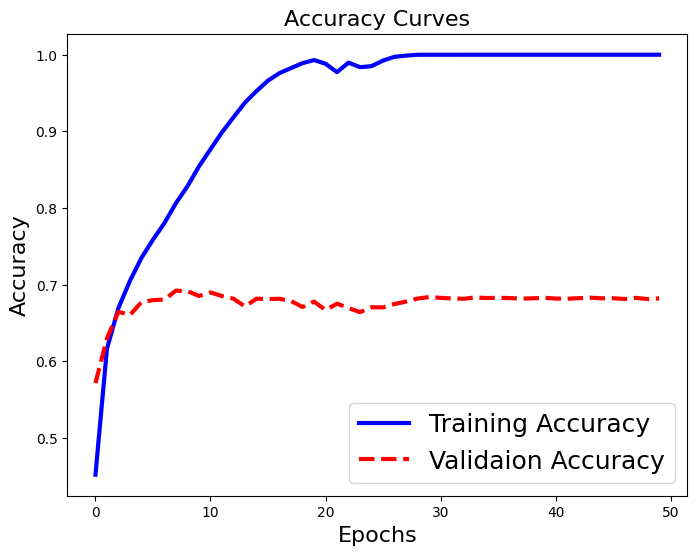

In [37]:
# Call the result_plotting() to display the results from your code
result_plotting()

# 07: Compare the results between the orinal model made using keras.Sequential VS the bigger model with at least 1 extra layer added.  Describe what are the differences between them.

**Answer:**

The bigger model achieved higher training accuracy compared to the original model, which indicates that it was able to learn more complex features from the data.

However, it also showed stronger signs of overfitting. The training accuracy increased significantly, while the validation accuracy stopped improving and slightly decreased after some epochs.

This means that although the bigger model is more powerful, it generalizes worse than the original model.

# 08: Add a dropout layer to your model, run it, and compare the result with the previous one.

> Hint 1: Here is a good explanation on how dropouts work https://www.youtube.com/watch?v=bRyOi0L6Rs8

> Hint 2: Don't modify the given code. Instead, copy and paste the given code below, then:
1. Modify it to add a dropout layer
2. Run the cell below containing the fucntions ```model.compile()``` and ```model.fit()```.
3. Once the training is complete, run the following cell containing the ```result_plotting()``` function




In [38]:
# Type your code here


model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')
])

In [39]:
# Compile your new model
model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])

# Train the Neural Network with your new model
history = model.fit(train_images,
                    train_labels,
                    epochs=50,
                    batch_size=256,
                    verbose=0,
                    validation_data=(test_images,test_labels),
                    callbacks=[cc])

 Finished epoch # 0
Accuracy resched train is 0.26673999428749084
Accuracy reached val is 0.42559999227523804

 Finished epoch # 5
Accuracy resched train is 0.4676800072193146
Accuracy reached val is 0.5435000061988831

 Finished epoch # 10
Accuracy resched train is 0.523419976234436
Accuracy reached val is 0.5891000032424927

 Finished epoch # 15
Accuracy resched train is 0.5507599711418152
Accuracy reached val is 0.6215000152587891

 Finished epoch # 20
Accuracy resched train is 0.5701799988746643
Accuracy reached val is 0.6263999938964844

 Finished epoch # 25
Accuracy resched train is 0.5827400088310242
Accuracy reached val is 0.6348000168800354

 Finished epoch # 30
Accuracy resched train is 0.6033599972724915
Accuracy reached val is 0.6420999765396118

 Finished epoch # 35
Accuracy resched train is 0.6137400269508362
Accuracy reached val is 0.6419000029563904

 Finished epoch # 40
Accuracy resched train is 0.6198199987411499
Accuracy reached val is 0.6468999981880188

 Finished e

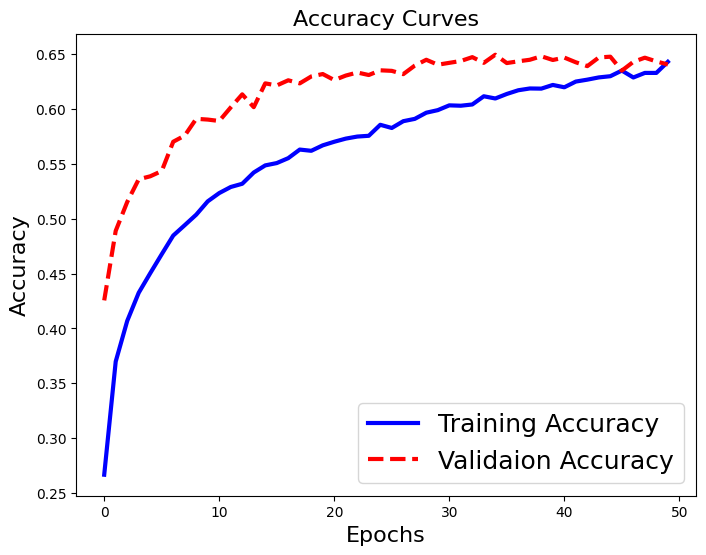

In [40]:
# Call the result_plotting() to display the results from your code
result_plotting()

# 09: Explain with your own words what is the purpose of a dropout layer and how it works. And briefly explain in your video in your own words.

**Answer:**

A dropout layer is used to reduce overfitting in neural networks.

During training, dropout randomly disables a fraction of neurons in the network. This prevents the model from relying too heavily on specific neurons and forces it to learn more general and robust features.

As a result, the model typically trains more slowly and may achieve lower training accuracy, but it generalizes better to unseen data and reduces overfitting.

Submission Instructions:
- YOU MUST SUBMIT A LINK TO YOUR ONLINE VIDEO (Youtube, Vimeo, etc) as a COMENTS SUBMISSION SECTION on your D2L SUBMISSION. Omitting this comment will result in a 0% for your total mark. Video should be between 5-15 minutes. Please remember to make your video unlisted or public, but it cannot be private. Please verify it's accessible using an incongito tab.  (5%)

- The Assignment03 **ipynb file** that contains all the code. (5%)
